# EDA — OP_AURUM_extract.csv

Analisis exploratorio del extracto de telemetria OPUS-MINE de la Unidad Minera La Cornisa.
Su proposito es sostener con evidencia las decisiones del Modulo A: que trata el imputador
como valor faltante, que features tienen sentido de dominio, que variables no pueden entrar
al modelo y como se plantea la validacion temporal.

El diccionario de variables y el analisis conceptual estan en `docs/diccionario_variables.md`.

**Ejecucion.** El CSV no se versiona en el repositorio. El notebook lo busca en la variable
de entorno `AURUM_CSV_PATH` y, si no esta definida, en el directorio `insumos/` hermano del
repositorio.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paleta y estilo. Roles semanticos, no valores sueltos repartidos por el notebook.
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
CRITICAL = "#d03b3b"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 9,
    "figure.dpi": 110,
    "legend.frameon": False,
})

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def locate_csv() -> Path:
    env = os.environ.get("AURUM_CSV_PATH")
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        candidate = parent / "insumos" / "OP_AURUM_extract.csv"
        if candidate.exists():
            return candidate
        candidate = parent.parent / "insumos" / "OP_AURUM_extract.csv"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Define AURUM_CSV_PATH con la ruta a OP_AURUM_extract.csv")


CSV_PATH = locate_csv()
df = pd.read_csv(CSV_PATH, parse_dates=["ts_opus_utc"])
print(f"origen : {CSV_PATH.name}")
print(f"filas  : {len(df):,}")
print(f"columnas: {df.shape[1]}")

origen : OP_AURUM_extract.csv
filas  : 50,000
columnas: 18


## 1. Forma, tipos y completitud

Primera pregunta: que hay y que falta. La distincion importante es entre el faltante
declarado (`NaN`) y el faltante codificado dentro del dominio numerico, que ninguna cuenta
de nulos detecta.

In [2]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(),
    "ejemplo": [df[c].dropna().iloc[0] for c in df.columns],
})
resumen

,tipo,nulos,pct_nulos,unicos,ejemplo
ts_opus_utc,datetime64[us],0,0.00,50000,2023-07-01 00:16:00
frente_id,str,0,0.00,13,FR-C1-05
turno_cod,str,0,0.00,4,N1
ley_au_gpT,float64,0,0.00,39635,8.0641
ton_rom_acum,float64,0,0.00,31432,273.32
pres_hidraul_bar,float64,0,0.00,1281,204.1
rpm_corona,int64,0,0.00,560,1042
avance_mmin,float64,0,0.00,2370,1.288
agua_iny_lmin,float64,0,0.00,6105,65.4
vibracion_rms_ms2,float64,0,0.00,8576,4.0


In [3]:
print("filas duplicadas completas:", df.duplicated().sum())
print("timestamps duplicados     :", df["ts_opus_utc"].duplicated().sum())
print()
for col in ["frente_id", "sector_geol", "tipo_mineral", "turno_cod", "equipo_id", "op_id"]:
    print(f"{col:14s} {df[col].nunique():>3d} categorias")

filas duplicadas completas: 0
timestamps duplicados     : 0

frente_id       13 categorias
sector_geol      4 categorias
tipo_mineral     4 categorias
turno_cod        4 categorias
equipo_id       10 categorias
op_id           18 categorias


`falla_cod` concentra casi todos los nulos y no es un dato perdido: nulo significa operacion
normal. `prod_estimada_oz` tiene 2810 nulos cuyo origen se explica en la seccion 6.

`frente_id` y `sector_geol` no son independientes. El prefijo de zona del codigo de frente
determina el sector, de modo que son la misma jerarquia a dos granularidades.

In [4]:
pd.crosstab(df["sector_geol"], df["frente_id"]).replace(0, "")

frente_id,FR-C1-01,FR-C1-05,FR-C2-02,FR-C2-07,FR-N1-03,FR-N1-07,FR-N2-01,FR-N2-04,FR-N2-09,FR-S1-02,FR-S1-06,FR-S2-03,FR-S2-08
sector_geol,,,,,,,,,,,,,
Cuerpo-Central,3483,4908,,,,,,,,,,,
Rampa-Norte,,,,,3481,4081,3459,4477,3875,,,,
Veta-Principal,,,3528,4277,,,,,,,,,
Veta-Sur,,,,,,,,,,3155,4022,2801,4453


## 2. Cobertura temporal y cadencia

La estructura temporal condiciona toda la validacion del Modulo A: con datos ordenados en el
tiempo, una particion aleatoria entrena con el futuro y valida con el pasado.

In [5]:
ts = df["ts_opus_utc"]
span_meses = (ts.max() - ts.min()).days / 30.44
print(f"inicio : {ts.min()}")
print(f"fin    : {ts.max()}")
print(f"span   : {span_meses:.1f} meses  (el enunciado describe 18)")

gaps = df.sort_values("ts_opus_utc").groupby("frente_id")["ts_opus_utc"].diff().dt.total_seconds().div(60)
print()
print("intervalo entre eventos del mismo frente (minutos):")
print(gaps.describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(1).to_string())

inicio : 2023-07-01 00:16:00
fin    : 2025-10-28 07:59:00
span   : 27.9 meses  (el enunciado describe 18)

intervalo entre eventos del mismo frente (minutos):
count     49987.0
mean        307.9
std        3407.9
min          15.0
25%          20.0
50%          25.0
75%          30.0
95%          34.0
max      166274.0


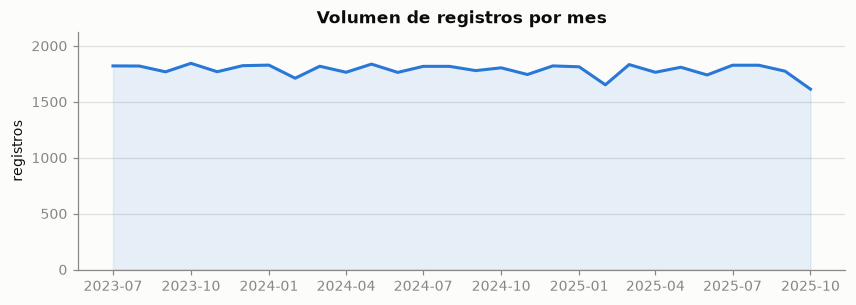

In [6]:
por_mes = df.set_index("ts_opus_utc").resample("MS").size()

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(por_mes.index, por_mes.values, color=SERIES[0], linewidth=2)
ax.fill_between(por_mes.index, por_mes.values, color=SERIES[0], alpha=0.10)
ax.set_ylim(0, por_mes.max() * 1.15)
ax.set_ylabel("registros")
ax.set_title("Volumen de registros por mes")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.show()

El volumen mensual es plano: el extracto es un muestreo regular, no una operacion con
estacionalidad de produccion. No hay huecos de meses completos ni un tramo inicial de
arranque que haya que descartar.

## 3. El turno es una particion determinista de la hora

`turno_cod` no aporta informacion independiente del timestamp. Verificarlo importa porque el
Modulo B pide reasignar el turno tras convertir a hora local, y esa conversion necesita un
desfase justificado.

In [7]:
turno_hora = pd.crosstab(df["ts_opus_utc"].dt.hour, df["turno_cod"])
turno_hora = turno_hora[["D1", "D2", "N1", "N2"]]
print("Horas UTC cubiertas por cada turno:")
for turno in turno_hora.columns:
    horas = sorted(turno_hora.index[turno_hora[turno] > 0].tolist())
    print(f"  {turno}: {horas}")
print()
print("filas donde la hora UTC no determina el turno:",
      int((turno_hora.gt(0).sum(axis=1) > 1).sum()))

Horas UTC cubiertas por cada turno:
  D1: [11, 12, 13, 14, 15, 16]
  D2: [17, 18, 19, 20, 21, 22]
  N1: [0, 1, 2, 3, 4, 23]
  N2: [5, 6, 7, 8, 9, 10]

filas donde la hora UTC no determina el turno: 0


Cada hora UTC pertenece a un unico turno, con fronteras en 05:00, 11:00, 17:00 y 23:00 UTC.
Restando cinco horas se obtienen turnos de seis horas que empiezan a las 00:00, 06:00, 12:00
y 18:00 hora local: **la zona operacional es UTC-5** (Peru), y el orden cronologico del dia
local es N2, D1, D2, N1. Ese es el desfase que usara la capa Silver.

## 4. `ley_au_gpT`: el valor especial es un centinela

El enunciado advierte que la ley "puede contener valores especiales". No son nulos: estan
codificados dentro del rango numerico.

In [8]:
ley = df["ley_au_gpT"]
print(ley.describe().round(4).to_string())
print()
print("valores negativos:", int((ley < 0).sum()), "| valores distintos negativos:", sorted(ley[ley < 0].unique()))
print("valores en cero  :", int((ley == 0).sum()))
print("nulos declarados :", int(ley.isna().sum()))

count    50000.0000
mean         7.4927
std          4.2761
min         -1.0000
25%          4.4118
50%          7.0836
75%         10.3580
max         25.7603

valores negativos: 2810 | valores distintos negativos: [np.float64(-1.0)]
valores en cero  : 0
nulos declarados : 0


El unico valor negativo es exactamente `-1.0`, en 2810 registros (5.6%). Una ley de oro
negativa no existe fisicamente: es el codigo de "sin lectura valida de la sonda XRF". Debe
tratarse como faltante antes de cualquier estadistica, o contamina toda media y todo
rolling.

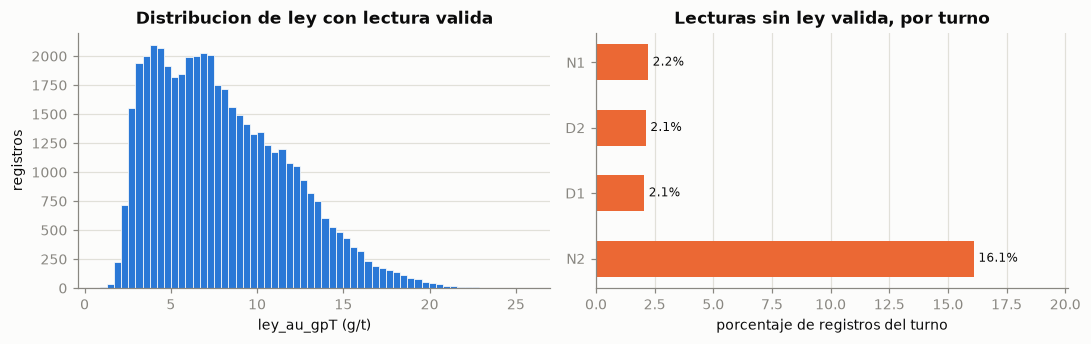

In [9]:
SENTINELA = -1.0
df["ley_sentinela"] = df["ley_au_gpT"].eq(SENTINELA)
ley_valida = df.loc[~df["ley_sentinela"], "ley_au_gpT"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].hist(ley_valida, bins=60, color=SERIES[0], edgecolor=SURFACE, linewidth=0.5)
axes[0].set_title("Distribucion de ley con lectura valida")
axes[0].set_xlabel("ley_au_gpT (g/t)")
axes[0].set_ylabel("registros")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)

tasa = df.groupby("turno_cod")["ley_sentinela"].mean().mul(100).reindex(["N2", "D1", "D2", "N1"])
barras = axes[1].barh(tasa.index, tasa.values, color=SERIES[1], height=0.55)
axes[1].bar_label(barras, fmt="%.1f%%", padding=3, color=INK, fontsize=8)
axes[1].set_xlim(0, tasa.max() * 1.25)
axes[1].set_title("Lecturas sin ley valida, por turno")
axes[1].set_xlabel("porcentaje de registros del turno")
axes[1].grid(axis="x")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

La ausencia de lectura **no es aleatoria**: el turno N2 concentra el 16.1% de sus registros
sin ley, frente a cerca del 2% en los otros tres. Es un faltante condicionado a una variable
observada, no un faltante completamente al azar.

Dos consecuencias para `AurumImputer`:

1. Imputar con la mediana del mismo frente y tipo de mineral es defendible porque la ley
   depende de la ubicacion (seccion 7), pero la imputacion debe dejar rastro: si el turno N2
   se imputa cinco veces mas que el resto, un modelo que no vea `flag_imputed` no puede
   distinguir un valor medido de uno reconstruido.
2. La regla de no imputar con menos de cinco registros disponibles no es una salvaguarda
   teorica. La distribucion de tamanos de la ventana de siete dias por frente y tipo de
   mineral decide con que frecuencia se activa.

In [10]:
ventana = (df.assign(fecha=df["ts_opus_utc"].dt.floor("D"))
             .loc[~df["ley_sentinela"]]
             .groupby(["frente_id", "tipo_mineral"])
             .size())
print("registros con ley valida por combinacion frente x tipo_mineral:")
print(ventana.describe().round(1).to_string())
print()
print("combinaciones existentes:", len(ventana), "de", df["frente_id"].nunique() * df["tipo_mineral"].nunique(), "posibles")

registros con ley valida por combinacion frente x tipo_mineral:
count      52.0
mean      907.5
std       270.8
min       357.0
25%       731.8
50%       943.5
75%      1117.5
max      1359.0

combinaciones existentes: 52 de 52 posibles


## 5. Sensores contra los rangos del diccionario

El diccionario publica rangos operacionales. Eso permite construir banderas de anomalia con
criterio de dominio en lugar de percentiles arbitrarios. Un valor fuera de rango no es ruido
a recortar: es el evento que interesa detectar.

In [11]:
RANGOS = {
    "pres_hidraul_bar": (180, 240, "rango normal"),
    "rpm_corona": (800, 1400, "rango operacional"),
    "vibracion_rms_ms2": (None, 12, "alerta operacional"),
    "temp_motor_c": (None, 95, "apagado automatico"),
}

filas = []
for col, (lo, hi, etiqueta) in RANGOS.items():
    fuera_bajo = int((df[col] < lo).sum()) if lo is not None else 0
    fuera_alto = int((df[col] > hi).sum()) if hi is not None else 0
    filas.append({
        "sensor": col,
        "criterio": etiqueta,
        "limite": f"{lo if lo is not None else ''}-{hi}".strip("-"),
        "observado": f"{df[col].min():.1f} a {df[col].max():.1f}",
        "bajo_limite": fuera_bajo,
        "sobre_limite": fuera_alto,
        "pct_fuera": round((fuera_bajo + fuera_alto) / len(df) * 100, 2),
    })
pd.DataFrame(filas)

,sensor,criterio,limite,observado,bajo_limite,sobre_limite,pct_fuera
0,pres_hidraul_bar,rango normal,180-240,140.0 a 270.0,2415,2333,9.50
1,rpm_corona,rango operacional,800-1400,820.0 a 1379.0,0,0,0.00
2,vibracion_rms_ms2,alerta operacional,12,0.5 a 19.6,0,140,0.28
3,temp_motor_c,apagado automatico,95,38.0 a 108.5,0,922,1.84


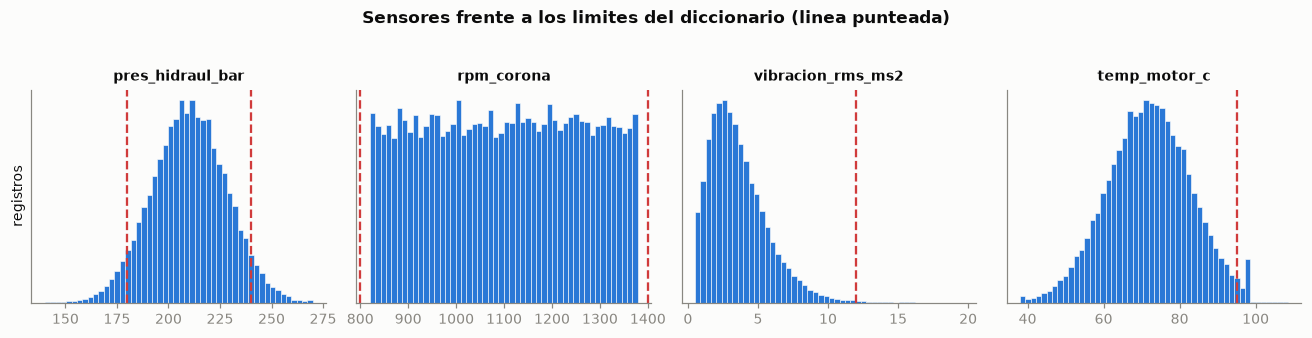

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.9))
for ax, (col, (lo, hi, _)) in zip(axes, RANGOS.items()):
    ax.hist(df[col], bins=50, color=SERIES[0], edgecolor=SURFACE, linewidth=0.4)
    for limite in (lo, hi):
        if limite is not None:
            ax.axvline(limite, color=CRITICAL, linewidth=1.5, linestyle="--")
    ax.set_title(col, fontsize=9)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.set_yticks([])
axes[0].set_ylabel("registros")
fig.suptitle("Sensores frente a los limites del diccionario (linea punteada)", y=1.04, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

La presion hidraulica sale de su banda en cerca del 10% de los registros, mientras que las
RPM nunca salen de la suya: el limite de RPM parece impuesto por el propio equipo y no
discrimina nada, asi que una bandera sobre RPM seria una columna constante. Las excedencias
utiles son las de presion, vibracion y temperatura.

## 6. `prod_estimada_oz` es una funcion de la ley, no una medicion

El enunciado ya lo advierte entre parentesis: "calculada, no medida directamente". El dato
permite recuperar la formula.

In [13]:
valida = df.loc[~df["ley_sentinela"]].copy()
OZ_TROY_G = 31.1035
valida["ratio"] = valida["prod_estimada_oz"] / (valida["ley_au_gpT"] * valida["ton_rom_acum"] / OZ_TROY_G)
pd.crosstab(valida["tipo_mineral"], valida["ratio"].round(2)).replace(0, "")

ratio,0.10,0.83,0.87,0.91
tipo_mineral,,,,
EST,6730,,,
MIX,,13484,,
OX,,,13538,
SUL,,,,13438


In [14]:
RECUPERACION = {"OX": 0.87, "SUL": 0.91, "MIX": 0.83, "EST": 0.10}
reconstruida = (valida["ley_au_gpT"] * valida["ton_rom_acum"] / OZ_TROY_G
                * valida["tipo_mineral"].map(RECUPERACION))
residuo = reconstruida - valida["prod_estimada_oz"]
ss_res = float((residuo ** 2).sum())
ss_tot = float(((valida["prod_estimada_oz"] - valida["prod_estimada_oz"].mean()) ** 2).sum())

print("prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)")
print(f"  R2                 : {1 - ss_res / ss_tot:.12f}")
print(f"  error absoluto max : {residuo.abs().max():.2e} oz")
print()
print("nula exactamente donde la ley es centinela:",
      bool((df['prod_estimada_oz'].isna() == df['ley_sentinela']).all()))

prod_estimada_oz = ley_au_gpT * ton_rom_acum / 31.1035 * recuperacion(tipo_mineral)
  R2                 : 0.999999999972
  error absoluto max : 6.45e-04 oz

nula exactamente donde la ley es centinela: True


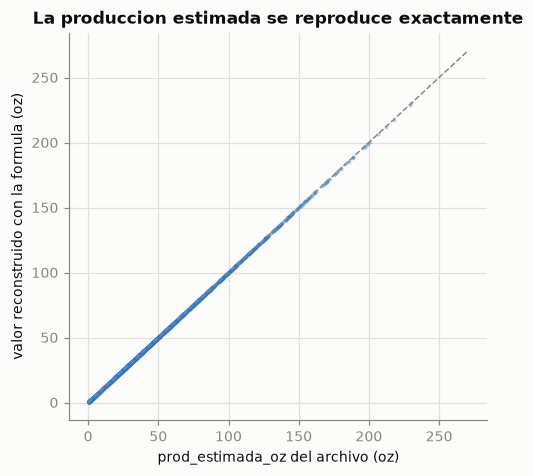

In [15]:
muestra = valida.sample(3000, random_state=7)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(muestra["prod_estimada_oz"], reconstruida.loc[muestra.index],
           s=6, color=SERIES[0], alpha=0.35, linewidths=0)
limite = float(valida["prod_estimada_oz"].max()) * 1.02
ax.plot([0, limite], [0, limite], color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("prod_estimada_oz del archivo (oz)")
ax.set_ylabel("valor reconstruido con la formula (oz)")
ax.set_title("La produccion estimada se reproduce exactamente")
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

> **Respuesta al bloque obligatorio del Ejercicio A-2 — por que NO usar `prod_estimada_oz`
> como feature para predecir `ley_au_gpT`.**
>
> Porque no es una variable independiente: es la propia ley multiplicada por el tonelaje y
> por un factor de recuperacion metalurgica que solo depende del tipo de mineral. La
> reconstruccion ajusta con R2 de 0.999999999972 y error maximo de 6.5e-4 oz, atribuible al
> redondeo del archivo a cuatro decimales. Despejando, `ley = prod_estimada_oz * 31.1035 /
> (ton_rom_acum * recuperacion)`: el modelo no aprenderia geologia, aprenderia a invertir
> una division. El ajuste en validacion seria casi perfecto y el modelo no serviria, por dos
> razones que se refuerzan. Primera, causalidad invertida: OPUS calcula la produccion a
> partir de la ley, de modo que usarla como entrada es explicar la causa con su consecuencia.
> Segunda, disponibilidad temporal: se quiere predecir la ley del **turno siguiente**, y la
> produccion estimada de ese turno no existe todavia en el momento de la prediccion,
> precisamente porque se calcula con la ley que falta. La prueba definitiva esta en los
> datos: `prod_estimada_oz` es nula exactamente en los 2810 registros donde la ley es
> centinela, sin una sola excepcion. La columna no acompana a la ley, depende de ella.
>
> El analisis previo que la habilitaria es el que se hizo aqui: recuperar la relacion
> funcional y comprobar que es determinista. Con ese resultado, el uso legitimo de la
> variable es como **lag** — la produccion estimada de turnos **anteriores** ya cerrados, que
> si esta disponible en tiempo de prediccion y aporta el mismo contenido que un lag de la
> ley, o como insumo del KPI de produccion del Modulo B. Nunca contemporanea al objetivo.

## 7. Que explica la ley: la geologia, no la maquina

La ley de oro es una propiedad del macizo rocoso. Los sensores describen como se perfora, no
cuanto oro hay. La hipotesis de dominio es que la senal viene de la ubicacion; conviene
verificarla antes de construir features.

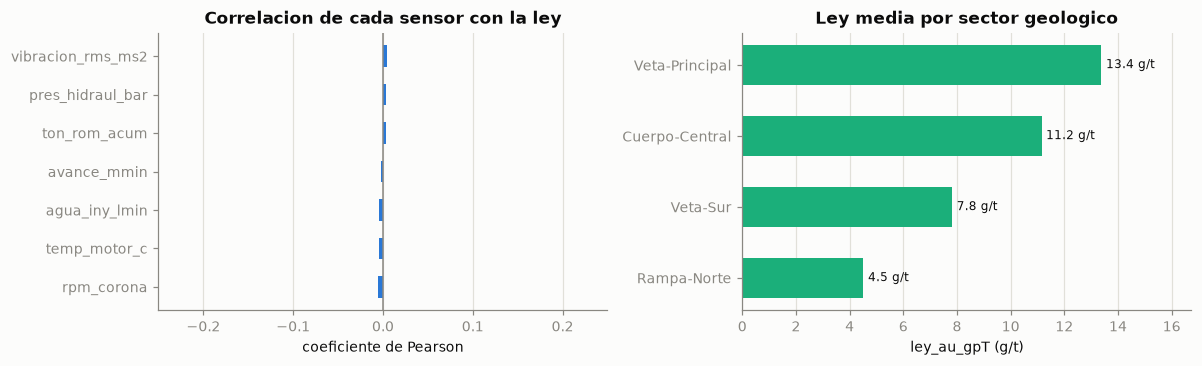

In [16]:
sensores = ["pres_hidraul_bar", "rpm_corona", "avance_mmin", "agua_iny_lmin",
            "vibracion_rms_ms2", "temp_motor_c", "ton_rom_acum"]
corr = valida[sensores + ["ley_au_gpT"]].corr()["ley_au_gpT"].drop("ley_au_gpT").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].barh(corr.index, corr.values, color=SERIES[0], height=0.55)
axes[0].axvline(0, color=MUTED, linewidth=1)
axes[0].set_xlim(-0.25, 0.25)
axes[0].set_title("Correlacion de cada sensor con la ley")
axes[0].set_xlabel("coeficiente de Pearson")
axes[0].grid(axis="x")
axes[0].set_axisbelow(True)

por_sector = valida.groupby("sector_geol")["ley_au_gpT"].mean().sort_values()
barras = axes[1].barh(por_sector.index, por_sector.values, color=SERIES[2], height=0.55)
axes[1].bar_label(barras, fmt="%.1f g/t", padding=3, color=INK, fontsize=8)
axes[1].set_xlim(0, por_sector.max() * 1.25)
axes[1].set_title("Ley media por sector geologico")
axes[1].set_xlabel("ley_au_gpT (g/t)")
axes[1].grid(axis="x")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

In [17]:
comparacion = pd.DataFrame({
    "por sector_geol": valida.groupby("sector_geol")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por frente_id": valida.groupby("frente_id")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por tipo_mineral": valida.groupby("tipo_mineral")["ley_au_gpT"].mean().agg(["min", "max"]),
    "por turno_cod": valida.groupby("turno_cod")["ley_au_gpT"].mean().agg(["min", "max"]),
}).T
comparacion["rango"] = (comparacion["max"] - comparacion["min"]).round(2)
comparacion.round(2)

,min,max,rango
por sector_geol,4.52,13.38,8.87
por frente_id,2.89,15.30,12.41
por tipo_mineral,7.97,8.03,0.06
por turno_cod,7.99,8.02,0.04


Ningun sensor de maquina supera 0.01 de correlacion con la ley. La ubicacion si separa: entre
sectores la media va de 4.5 a 13.4 g/t. `tipo_mineral` en cambio no discrimina la ley, lo
cual es contraintuitivo desde el dominio y conviene declararlo: en este extracto el tipo de
mineral influye en la recuperacion metalurgica, no en el contenido de oro.

Para `AurumShiftEncoder` esto significa que el target encoding de `frente_id` es la feature
mas fuerte disponible, y por eso mismo la mas expuesta a fuga: con trece frentes y 50000
filas, codificar un frente con una media que incluye la propia fila inflaria la metrica de
validacion. El leave-one-out es obligatorio, no opcional.

## 8. Fallas: prevalencia, subsistemas y precursores

In [18]:
df["falla"] = df["falla_cod"].notna()
print(f"prevalencia global: {df['falla'].mean() * 100:.2f}%  ({int(df['falla'].sum())} de {len(df):,})")
print()
codigos = df["falla_cod"].value_counts().rename_axis("codigo").to_frame("eventos")
codigos["subsistema"] = codigos.index.str.split("-").str[1]
print(codigos.to_string())

prevalencia global: 3.32%  (1659 de 50,000)

            eventos subsistema
codigo                        
E-ELEC-01       227       ELEC
M-MOTOR-07      219      MOTOR
H-HIDRA-02      210      HIDRA
B-BOMBA-01      209      BOMBA
H-HIDRA-05      202      HIDRA
M-MOTOR-03      202      MOTOR
S-SELLO-02      198      SELLO
E-ELEC-04       192       ELEC


In [19]:
comparacion_falla = (df.groupby("falla")[["temp_motor_c", "vibracion_rms_ms2", "pres_hidraul_bar",
                                          "rpm_corona", "avance_mmin", "agua_iny_lmin"]]
                       .mean().T)
comparacion_falla.columns = ["sin falla", "con falla"]
comparacion_falla["delta"] = comparacion_falla["con falla"] - comparacion_falla["sin falla"]
comparacion_falla.round(2)

,sin falla,con falla,delta
temp_motor_c,71.61,81.38,9.76
vibracion_rms_ms2,3.59,3.72,0.13
pres_hidraul_bar,210.01,209.13,-0.88
rpm_corona,1099.78,1100.65,0.86
avance_mmin,1.80,1.79,-0.01
agua_iny_lmin,45.06,44.95,-0.11


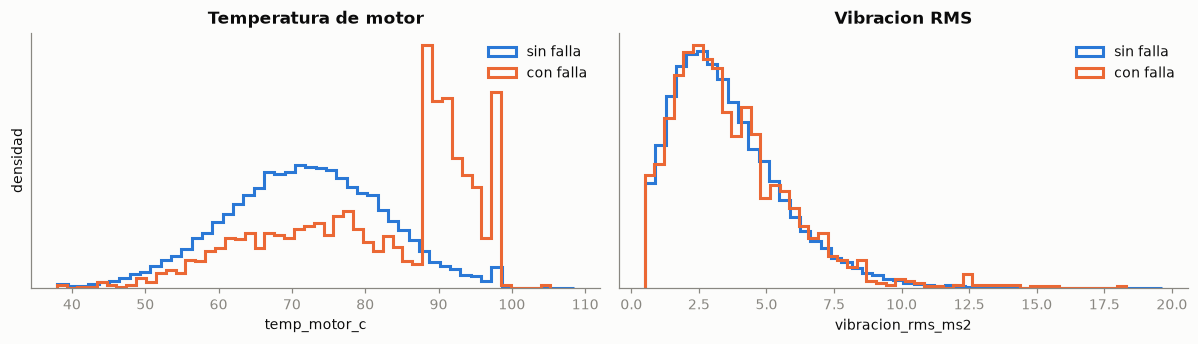

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

for ax, col, titulo in zip(axes,
                           ["temp_motor_c", "vibracion_rms_ms2"],
                           ["Temperatura de motor", "Vibracion RMS"]):
    for etiqueta, color, mascara in [("sin falla", SERIES[0], ~df["falla"]),
                                     ("con falla", SERIES[1], df["falla"])]:
        ax.hist(df.loc[mascara, col], bins=50, density=True, histtype="step",
                linewidth=2, color=color, label=etiqueta)
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_yticks([])
    ax.legend()
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].set_ylabel("densidad")

plt.tight_layout()
plt.show()

In [21]:
condiciones = {
    "temp_motor_c > 95": df["temp_motor_c"] > 95,
    "vibracion_rms_ms2 > 12": df["vibracion_rms_ms2"] > 12,
    "presion fuera de 180-240": ~df["pres_hidraul_bar"].between(180, 240),
    "flag_mant_prev = 1": df["flag_mant_prev"].eq(1),
    "linea base (todos)": pd.Series(True, index=df.index),
}
pd.DataFrame([
    {"condicion": nombre,
     "registros": int(mascara.sum()),
     "tasa_falla_pct": round(df.loc[mascara, "falla"].mean() * 100, 2)}
    for nombre, mascara in condiciones.items()
])

,condicion,registros,tasa_falla_pct
0,temp_motor_c > 95,922,22.02
1,vibracion_rms_ms2 > 12,140,17.14
2,presion fuera de 180-240,4748,4.32
3,flag_mant_prev = 1,1213,2.80
4,linea base (todos),50000,3.32


La temperatura de motor es el unico precursor claro: casi diez grados de diferencia en media
y una tasa de falla del 22% sobre el umbral de apagado, frente al 3.3% de base. La vibracion
separa poco en media, aunque sus excedencias tambien multiplican por cinco la tasa de falla.
La presion fuera de banda no discrimina.

Dos hallazgos con lectura operacional directa:

- El **mantenimiento preventivo no reduce la tasa de falla** de forma apreciable (2.8% dentro
  de la ventana contra 3.3% fuera). Si el programa preventivo funcionara, la diferencia
  deberia ser mayor; vale la pena reportarlo al area de mantenimiento.
- Las fallas se reparten de forma casi uniforme entre los diez equipos, entre 2.8% y 3.6%.
  No hay un equipo problematico: el riesgo esta en la condicion de operacion, no en el activo.

Para el clasificador de las proximas cuatro horas, con 3.3% de positivos, la metrica no puede
ser accuracy — un modelo que siempre diga "sin falla" acierta el 96.7%. La discusion de
metrica se desarrolla en el Ejercicio A-2.

## 9. `ton_rom_acum` no se comporta como un acumulado

El diccionario lo define como toneladas acumuladas en el turno. Si lo fuera, dentro de un
mismo frente, fecha y turno la serie tendria que ser creciente.

In [22]:
orden = df.sort_values("ts_opus_utc").assign(fecha_local=lambda d: (d["ts_opus_utc"] - pd.Timedelta(hours=5)).dt.date)
monotona = (orden.groupby(["frente_id", "fecha_local", "turno_cod"])["ton_rom_acum"]
                 .apply(lambda s: bool(s.is_monotonic_increasing)))
print(f"grupos frente x fecha x turno      : {len(monotona):,}")
print(f"con ton_rom_acum creciente         : {monotona.mean() * 100:.1f}%")
print(f"registros por grupo (mediana)      : {orden.groupby(['frente_id', 'fecha_local', 'turno_cod']).size().median():.0f}")

grupos frente x fecha x turno      : 4,019
con ton_rom_acum creciente         : 4.0%
registros por grupo (mediana)      : 14


Solo una fraccion marginal de los grupos es creciente. El campo no es un contador acumulado
del turno pese a su nombre; se comporta como el tonelaje del evento. La consecuencia es para
la capa Gold del Modulo B: la ley promedio ponderada por tonelaje debe **sumar**
`ton_rom_acum`, no tomar el maximo del turno como haria con un acumulador. El supuesto queda
declarado en lugar de heredado del nombre de la columna.

## 10. Sintesis

| Hallazgo | Evidencia | Consecuencia |
|---|---|---|
| `ley_au_gpT` usa `-1.0` como centinela de "sin lectura" | unico valor negativo, 2810 registros | el imputador lo trata como faltante antes de cualquier estadistica |
| El faltante de ley no es aleatorio | 16.1% en N2 contra ~2.1% en el resto | `flag_imputed` conserva informacion; no imputar en silencio |
| `prod_estimada_oz` es funcion determinista de la ley | R2 = 0.999999999972 | excluida como feature contemporanea; admisible solo como lag |
| La ley la explica la ubicacion, no la maquina | correlacion de sensores < 0.01; sectores de 4.5 a 13.4 g/t | features centradas en frente, sector e historia reciente de ley |
| `frente_id` es el predictor mas fuerte | rango de medias por frente de 12.4 g/t | target encoding con leave-one-out es indispensable |
| El turno se deriva de la hora con desfase UTC-5 | cada hora UTC cae en un unico turno | la capa Silver recalcula el turno tras convertir a hora local |
| La temperatura de motor precede a la falla | 81.4 C con falla contra 71.6 C sin falla; 22% de falla sobre 95 C | features de temperatura, rolling y excedencias para el clasificador |
| El mantenimiento preventivo no reduce fallas | 2.8% dentro de la ventana contra 3.3% fuera | hallazgo operacional a reportar |
| `ton_rom_acum` no es acumulado | creciente en 4.0% de los grupos | el KPI ponderado suma, no maximiza |
| El extracto cubre 27.9 meses, no 18 | 2023-07-01 a 2025-10-28 | validacion temporal con corte por fecha, no aleatoria |